<a href="https://colab.research.google.com/github/larissa-natalie/analise-vendas-online/blob/main/aula18_09_rv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PRIMEIROS PASSOS DA ANALISE:

import pandas as pd

df_vendas = pd.read_csv("/content/vendas_loja_online.csv")

print("Quantidade de valores vazios: ")
print(df_vendas.isnull().sum())
# .isnull().sum() para verificar se tem dados em branco, ele olha e soma por coluna
# util para ver se as colunas vazias vao ter impacto na analise e entender oq fazer com os nulos
# daria para usar o .info() tambem

print('\n')

# ESTATISTICAS RESUMIDAS .describe()
print("Dados estatisticos resumidos: ")
print(df_vendas.describe())

print('\n')

print("Dados estatisticos resumidos incluindo os qualitativos(texto): ")
print(df_vendas.describe(include=object)) # (include=object) contabiliza as str

print('\n')

# dados repetidos
print("Informações repetidas e suas quantidades: ")
print(df_vendas.duplicated().sum())

Quantidade de valores vazios: 
order_date           0
product_category     0
sales_amount        17
quantity             0
customer_region      0
dtype: int64


Dados estatisticos resumidos: 
       sales_amount    quantity
count    243.000000  260.000000
mean    1062.230968    2.869231
std     3301.231839    1.419057
min       72.424181    1.000000
25%      219.901736    2.000000
50%      446.009108    3.000000
75%      700.300401    4.000000
max    32923.656776    5.000000


Dados estatisticos resumidos incluindo os qualitativos(texto): 
        order_date product_category customer_region
count          260              260             260
unique         176                4               4
top     2025-08-17         Esportes           Leste
freq             4               72              72


Informações repetidas e suas quantidades: 
10


In [ ]:
# LIMPAR DADOS - não tem regra, ordem, tudo depende da base e das instruções dadas

# 1º verificando os dados duplicados
linhas_duplicadas = df_vendas[df_vendas.duplicated(keep=False)] # keep=False pega os dados e mostra apenas os duplicados
print('Dados duplicados na base: ')
print('\n')
print(linhas_duplicadas.sort_values(by='order_date')) #essa linha mostra cada duplicado junto, melhor para visualizar e achar na base, senao usar ele mostra tudo misturado

print('\n')

# 2º remover os dados duplicados
df_vendas.drop_duplicates(inplace=True)
# mantem sempre a primeira opçao e exclui as outras
# .drop_duplicates exclui apenas as linhas q sao realmente iguais
display(df_vendas.head(10))

Dados duplicados na base: 


     order_date product_category  sales_amount  quantity customer_region
259  2025-02-10        Vestuário    166.599751         2           Leste
104  2025-02-10        Vestuário    166.599751         2           Leste
250  2025-03-07         Esportes    329.313353         3           Leste
142  2025-03-07         Esportes    329.313353         3           Leste
256  2025-05-30         Esportes    131.993224         1             Sul
197  2025-05-30         Esportes    131.993224         1             Sul
184  2025-06-11      Eletrônicos  32923.656776         4           Leste
257  2025-06-11      Eletrônicos  32923.656776         4           Leste
181  2025-07-08             Casa    135.791009         1           Norte
255  2025-07-08             Casa    135.791009         1           Norte
60   2025-07-31             Casa           NaN         3             Sul
253  2025-07-31             Casa           NaN         3             Sul
251  2025-08-17      E

,order_date,product_category,sales_amount,quantity,customer_region
0,2025-01-25,Casa,136.380079,1,Leste
1,2025-04-24,Esportes,435.909965,4,Leste
2,2025-10-15,Eletrônicos,NaN,5,Oeste
3,2025-01-19,Casa,NaN,1,Leste
4,2025-07-30,Casa,447.675645,3,Leste
5,2025-08-06,Esportes,331.044060,3,Leste
6,2025-08-17,Eletrônicos,499.161588,1,Norte
7,2025-06-13,Eletrônicos,2486.735885,5,Leste
8,2025-12-04,Casa,140.196056,1,Leste
9,2025-09-09,Vestuário,236.824879,3,Oeste


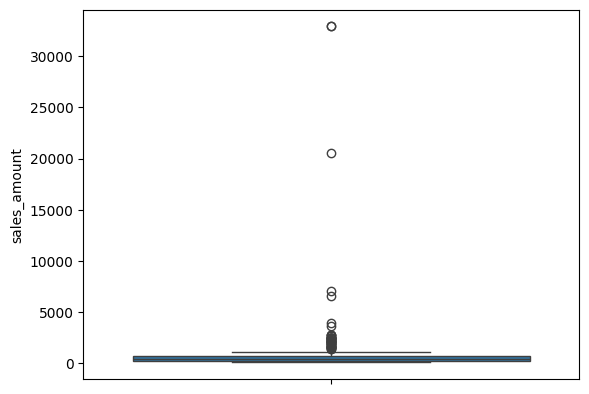



Média: 
1021.9395386107443
Mediana: 
446.0091077507142


In [75]:
# identificar se usamos a média ou a mediana nos valores nulos de sales (apenas se o gestor falar q deseja q esses nulos sejam preenchidos)

# verificar analise com um grafico estático
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(y=df_vendas['sales_amount'])
plt.show()
# pelo resultado do grafico vc consegue ver pelas bolinhas q tem muitos valores discrepantes (dispersão)
# logo a media nesse caso puxaria os valores para cima, entao o ideal é usar mediana para ficar mais proximo do "padrao" dos valores

print('\n')
#tirando a prova da diferença:
print('Média: ')
print(df_vendas['sales_amount'].mean())
print('Mediana: ')
print(df_vendas['sales_amount'].median())

In [ ]:
# mesma consulta, mas com GRAFICO INTERATIVO
import plotly.express as px
fig = px.box(df_vendas, y='sales_amount')
fig.show()

<Axes: ylabel='sales_amount'>

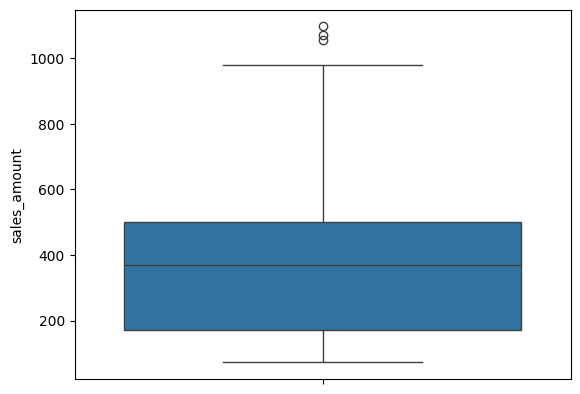

In [ ]:
# trabalhando os outrliers do grafico box para diminuir a visao dos valores discrepantes

q1 = df_vendas['sales_amount'].quantile(0.25)
q2 = df_vendas['sales_amount'].median()
q3 = df_vendas['sales_amount'].quantile(0.75)

#calculo de intervalo do quartil
#calculo pra descobrir as informações sem os outliers
iqr = q3 - q1
limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

df_vendas_sem_out = df_vendas[(df_vendas['sales_amount']>= limite_inferior) &
                              (df_vendas['sales_amount']<= limite_superior)]

sns.boxplot(y=df_vendas_sem_out['sales_amount'])

In [76]:
# confirmando se os nulos foram retirados

df_vendas['sales_amount'] = df_vendas['sales_amount'].fillna(df_vendas['sales_amount'].median())
print(df_vendas.isnull().sum())

order_date          0
product_category    0
sales_amount        0
quantity            0
customer_region     0
dtype: int64


In [52]:
# qntdd de vendas por regiao em TABELA

tabela_regiao = df_vendas_sem_out.groupby('customer_region')['quantity'].sum().reset_index()
tabela_regiao = tabela_regiao.sort_values(by='quantity',ascending=False)
display(tabela_regiao)

,customer_region,quantity
0,Leste,162
3,Sul,150
2,Oeste,135
1,Norte,132


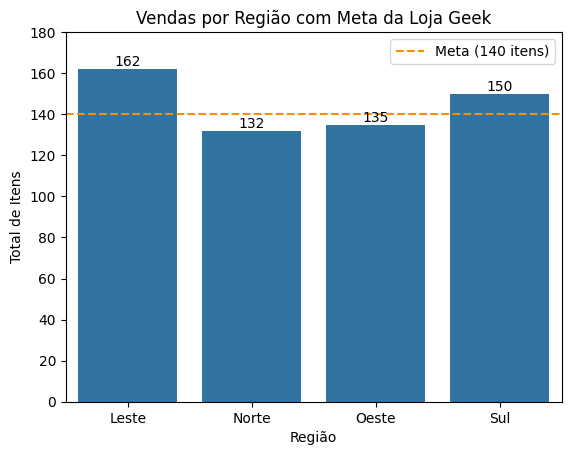

In [81]:
# qntdd de vendas por regiao em GRAFICO e com meta
tabela_regiao = df_vendas_sem_out.groupby('customer_region')['quantity'].sum().reset_index()

grafico = sns.barplot(x=tabela_regiao['customer_region'],
            y=tabela_regiao['quantity'])

plt.bar_label(grafico.containers[0])

#customização do gráfico
plt.axhline(y=140, color='darkorange', linestyle = '--', label='Meta (140 itens)') # axhline coloca uma linha horizontal no grafico, entre () vc insere os detalhes desejados
plt.title('Vendas por Região com Meta da Loja Geek') # titulo do grafico
plt.xlabel('Região') # identificação eixo x
plt.ylabel('Total de Itens') # identificação eixo y
plt.ylim(0, 180) # definindo o limite do eixo Y, (ond começa,ond termina)
plt.legend() # comando para exibir label no grafico
plt.show() # comando para mostrar o grafico

In [66]:
# exportar para csv e uso posterior no power BI
df_vendas_sem_out.to_csv('vendas_por_regiao.csv', index=False)
tabela_regiao.to_csv('tabela_regiao.csv', index=False)
print('dados salvos')

from google.colab import files
files.download('vendas_por_regiao.csv')

dados salvos


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>